# 🛡️ Real-Time Cyber Attack Prediction — Wazuh SIEM + Random Forest
---
**Environment:** On-Premise | **SIEM:** Wazuh 4.x | **Model:** Random Forest Classifier

This notebook covers the complete pipeline:
1. ⚙️ Configuration & Setup
2. 🔌 Wazuh SIEM Data Fetching (Live or Synthetic Fallback)
3. 🔍 Exploratory Data Analysis (EDA)
4. 🛠️ Feature Engineering
5. 🌲 Random Forest Model Training
6. 📊 Evaluation & Visualisation
7. 💾 Model Saving
8. ⚡ Real-Time Prediction Demo

> **Note:** If your Wazuh server is not reachable, the notebook automatically uses
> realistic synthetic Wazuh-shaped alert data so every cell runs end-to-end.


## ⚙️ Cell 1 — Install Dependencies

In [ ]:
import subprocess, sys

packages = [
    "scikit-learn", "pandas", "numpy", "matplotlib",
    "seaborn", "requests", "urllib3", "joblib",
    "opensearch-py", "ipywidgets"
]

for pkg in packages:
    subprocess.run(
        [sys.executable, "-m", "pip", "install", pkg, "-q",
         "--break-system-packages"],
        capture_output=True
    )

print("✅ All packages installed successfully.")


✅ All packages installed successfully.


## 📦 Cell 2 — Import Libraries

In [2]:
import warnings, os, re, json, time
warnings.filterwarnings("ignore")

import numpy  as np
import pandas as pd
import matplotlib.pyplot    as plt
import matplotlib.gridspec  as gridspec
import seaborn              as sns
import joblib
import requests

from datetime                import datetime, timedelta, timezone
from sklearn.ensemble        import RandomForestClassifier
from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     cross_val_score)
from sklearn.preprocessing   import LabelEncoder, label_binarize
from sklearn.metrics         import (classification_report, confusion_matrix,
                                     accuracy_score, f1_score, roc_auc_score)

requests.packages.urllib3.disable_warnings()

# Notebook display settings
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", "{:.4f}".format)

%matplotlib inline
plt.rcParams["figure.dpi"] = 110

print("✅ Libraries imported.")
print(f"   Pandas     : {pd.__version__}")
print(f"   NumPy      : {np.__version__}")
import sklearn; print(f"   Scikit-learn: {sklearn.__version__}")


✅ Libraries imported.
   Pandas     : 3.0.1
   NumPy      : 2.4.3
   Scikit-learn: 1.8.0


## ⚙️ Cell 3 — Wazuh Connection Configuration
> Edit the values below to point to your on-premise Wazuh deployment.


In [3]:
# ─── Wazuh Manager REST API ─────────────────────────────────────────
WAZUH_HOST     = "https://YOUR-WAZUH-IP"     # e.g. https://192.168.1.100
WAZUH_PORT     = 55000
WAZUH_USER     = "wazuh"
WAZUH_PASSWORD = "YOUR_PASSWORD"

# ─── Wazuh Indexer / OpenSearch ─────────────────────────────────────
INDEXER_HOST     = "https://YOUR-WAZUH-IP"   # usually same host
INDEXER_PORT     = 9200
INDEXER_USER     = "admin"
INDEXER_PASSWORD = "admin"

# ─── Fetch Settings ─────────────────────────────────────────────────
INDEX_PATTERN = "wazuh-alerts-*"
FETCH_HOURS   = 72          # hours of history to pull
MAX_ALERTS    = 20000       # max alert cap
MIN_LEVEL     = 1           # minimum Wazuh rule level (1–15)
VERIFY_SSL    = False       # set True if you have valid TLS certs

# ─── Output Directory ───────────────────────────────────────────────
OUTPUT_DIR = "./wazuh_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("✅ Configuration loaded.")
print(f"   Wazuh   : {WAZUH_HOST}:{WAZUH_PORT}")
print(f"   Indexer : {INDEXER_HOST}:{INDEXER_PORT}")
print(f"   Index   : {INDEX_PATTERN}")
print(f"   Fetch   : last {FETCH_HOURS}h  |  max {MAX_ALERTS} alerts")


✅ Configuration loaded.
   Wazuh   : https://YOUR-WAZUH-IP:55000
   Indexer : https://YOUR-WAZUH-IP:9200
   Index   : wazuh-alerts-*
   Fetch   : last 72h  |  max 20000 alerts


## 🔌 Cell 4 — Wazuh Manager Authentication
Authenticates with the Wazuh Manager REST API on port **55000** and retrieves a JWT token.


In [4]:
session = requests.Session()
session.verify = VERIFY_SSL
session.headers.update({"Content-Type": "application/json"})

wazuh_token = None

try:
    url  = f"{WAZUH_HOST}:{WAZUH_PORT}/security/user/authenticate"
    resp = session.post(url, auth=(WAZUH_USER, WAZUH_PASSWORD), timeout=8)

    if resp.status_code == 200:
        wazuh_token = resp.json()["data"]["token"]
        session.headers["Authorization"] = f"Bearer {wazuh_token}"
        print("✅ Wazuh Manager authenticated successfully.")
    else:
        print(f"⚠️  Auth failed — HTTP {resp.status_code}: {resp.text[:200]}")

except Exception as e:
    print(f"⚠️  Wazuh Manager unreachable: {e}")
    print("   → Will use synthetic data fallback in Cell 5.")


⚠️  Wazuh Manager unreachable: HTTPSConnectionPool(host='your-wazuh-ip', port=55000): Max retries exceeded with url: /security/user/authenticate (Caused by ProxyError('Unable to connect to proxy', OSError('Tunnel connection failed: 403 Forbidden')))
   → Will use synthetic data fallback in Cell 5.


## 📥 Cell 5 — Fetch Alerts from Wazuh Indexer (OpenSearch)
Pulls alerts from `wazuh-alerts-*` using the OpenSearch Scroll API.
Falls back to a **synthetic Wazuh dataset** if the server is unreachable.


In [5]:
# ── OpenSearch scroll fetch ──────────────────────────────────────────
def fetch_from_indexer(hours=72, max_alerts=20000):
    since = (datetime.now(timezone.utc) - timedelta(hours=hours)).isoformat()
    base  = f"{INDEXER_HOST}:{INDEXER_PORT}"
    auth  = (INDEXER_USER, INDEXER_PASSWORD)

    FIELDS = [
        "@timestamp", "rule.id", "rule.level", "rule.description",
        "rule.groups", "rule.mitre.id", "rule.mitre.tactic",
        "agent.id", "agent.name", "agent.ip",
        "data.srcip", "data.dstip", "data.srcport", "data.dstport",
        "data.protocol", "data.action", "data.status",
        "data.extra_data.count",
    ]

    query = {
        "size": 1000,
        "query": {"bool": {"must": [
            {"range": {"@timestamp": {"gte": since}}},
            {"range": {"rule.level":  {"gte": MIN_LEVEL}}},
        ]}},
        "_source": FIELDS,
    }

    alerts = []
    try:
        r = session.post(
            f"{base}/{INDEX_PATTERN}/_search?scroll=2m",
            auth=auth, json=query, timeout=30
        )
        r.raise_for_status()
        body      = r.json()
        scroll_id = body.get("_scroll_id")
        hits      = body["hits"]["hits"]
        alerts.extend([h["_source"] for h in hits])
        print(f"  First batch : {len(hits)} alerts")

        while hits and len(alerts) < max_alerts:
            r2 = session.post(
                f"{base}/_search/scroll",
                auth=auth, json={"scroll": "2m", "scroll_id": scroll_id},
                timeout=30,
            )
            r2.raise_for_status()
            body2     = r2.json()
            scroll_id = body2.get("_scroll_id", scroll_id)
            hits      = body2["hits"]["hits"]
            alerts.extend([h["_source"] for h in hits])
            print(f"  Fetched so far: {len(alerts)}")

    except Exception as e:
        print(f"  ⚠️  OpenSearch unreachable: {e}")

    return alerts[:max_alerts]


# ── Flatten nested JSON ──────────────────────────────────────────────
FIELD_MAP = {
    "timestamp":         "@timestamp",
    "rule_id":           "rule.id",
    "rule_level":        "rule.level",
    "rule_description":  "rule.description",
    "rule_groups":       "rule.groups",
    "rule_mitre_id":     "rule.mitre.id",
    "rule_mitre_tactic": "rule.mitre.tactic",
    "agent_id":          "agent.id",
    "agent_name":        "agent.name",
    "agent_ip":          "agent.ip",
    "src_ip":            "data.srcip",
    "dst_ip":            "data.dstip",
    "src_port":          "data.srcport",
    "dst_port":          "data.dstport",
    "protocol":          "data.protocol",
    "action":            "data.action",
    "status":            "data.status",
    "event_count":       "data.extra_data.count",
}

def parse_alerts(raw):
    def _get(doc, key):
        val = doc
        for k in key.split("."):
            val = val.get(k) if isinstance(val, dict) else None
        return val

    rows = []
    for doc in raw:
        row = {}
        for col, field in FIELD_MAP.items():
            v = _get(doc, field)
            row[col] = ",".join(str(x) for x in v) if isinstance(v, list) else v
        rows.append(row)
    return pd.DataFrame(rows)


# ── Synthetic Wazuh fallback ─────────────────────────────────────────
def generate_synthetic_wazuh(n=18000):
    rng = np.random.default_rng(42)

    profiles = {
        "Normal":          dict(frac=0.35, level=(1,5),   ports=[80,443,22,53],   failed=0),
        "BruteForce":      dict(frac=0.15, level=(5,10),  ports=[22,3389,445],    failed=5),
        "DoS":             dict(frac=0.12, level=(8,13),  ports=[80,443,8080],    failed=0),
        "Recon":           dict(frac=0.12, level=(4,8),   ports=list(range(1,1024,13)), failed=0),
        "WebAttack":       dict(frac=0.10, level=(7,12),  ports=[80,443,8080,8443],failed=1),
        "Malware":         dict(frac=0.07, level=(10,15), ports=[4444,1234,9999], failed=0),
        "Exploit":         dict(frac=0.05, level=(10,15), ports=[135,139,445],    failed=0),
        "LateralMovement": dict(frac=0.02, level=(9,14),  ports=[22,445,3389],    failed=2),
        "Exfiltration":    dict(frac=0.02, level=(9,14),  ports=[443,80,21,53],   failed=0),
    }

    rule_db = {
        "Normal":          [(5501,"sshd: Attempt to login using non-existent user"),
                            (1002,"Unknown problem somewhere in the system"),
                            (5103,"PAM: Login session opened.")],
        "BruteForce":      [(5712,"SSHD: SSH Brute Force Attempt"),
                            (5503,"User login failed"),
                            (18152,"Windows: Multiple authentication failures"),
                            (5551,"Multiple authentication failures on SSH")],
        "DoS":             [(31151,"Web server 400 error code"),
                            (40111,"Firewall: DoS attack detected"),
                            (31103,"Web server 503 error code (Unavailable)")],
        "Recon":           [(40101,"Firewall: Port scan from unknown host"),
                            (5400,"Host scan detected"),
                            (2054,"Nmap: Host scan detected")],
        "WebAttack":       [(31410,"SQL injection attempt"),
                            (31411,"XSS attempt detected"),
                            (31103,"Web server 403 error code (Forbidden)")],
        "Malware":         [(65002,"ClamAV: Malware detection"),
                            (553,"File modified"),
                            (554,"File added to the system")],
        "Exploit":         [(40115,"Exploit attempt detected"),
                            (22503,"Local privilege escalation attempt"),
                            (31513,"Web vulnerability scan")],
        "LateralMovement": [(18107,"Windows: Logon using explicit credentials"),
                            (18108,"Windows: Pass-the-Hash attack detected"),
                            (5706,"Possible attack on the SSH server")],
        "Exfiltration":    [(40140,"Large data transfer detected"),
                            (87002,"File access to sensitive data"),
                            (31201,"Web server: Large response detected")],
    }

    mitre_map = {
        "Normal":"discovery", "BruteForce":"credential_access",
        "DoS":"impact", "Recon":"reconnaissance",
        "WebAttack":"initial_access", "Malware":"execution",
        "Exploit":"privilege_escalation", "LateralMovement":"lateral_movement",
        "Exfiltration":"exfiltration",
    }

    agents = [{"id":f"00{i}","name":f"server-{i:02d}","ip":f"192.168.10.{10+i}"}
              for i in range(1, 16)]

    rows = []
    now  = datetime.now(timezone.utc)

    for label, p in profiles.items():
        nc = int(n * p["frac"])
        rules = rule_db[label]
        for i in range(nc):
            rid, rdesc = rules[i % len(rules)]
            ag = agents[i % len(agents)]
            ts = now - timedelta(seconds=int(rng.uniform(0, 72*3600)))
            rows.append({
                "timestamp":         ts.isoformat(),
                "rule_id":           rid,
                "rule_level":        int(rng.integers(p["level"][0], p["level"][1]+1)),
                "rule_description":  rdesc,
                "rule_groups":       label.lower() + ",ossec",
                "rule_mitre_id":     f"T{rng.integers(1000,1600)}",
                "rule_mitre_tactic": mitre_map[label],
                "agent_id":          ag["id"],
                "agent_name":        ag["name"],
                "agent_ip":          ag["ip"],
                "src_ip":            f"10.{rng.integers(0,255)}.{rng.integers(0,255)}.{rng.integers(1,254)}",
                "dst_ip":            ag["ip"],
                "src_port":          int(rng.integers(1024,65535)),
                "dst_port":          int(p["ports"][i % len(p["ports"])]),
                "protocol":          rng.choice(["tcp","udp","icmp"],p=[0.7,0.2,0.1]),
                "action":            rng.choice(["allow","deny","drop"],
                                     p=[0.6,0.2,0.2] if label=="Normal" else [0.1,0.5,0.4]),
                "status":            rng.choice(["success","failure"],
                                     p=[0.9,0.1] if label=="Normal" else [0.2,0.8]),
                "event_count":       int(rng.integers(1, 5 if label=="Normal" else 300)),
                "label":             label,
            })

    return pd.DataFrame(rows).sample(frac=1, random_state=42).reset_index(drop=True)


# ── Main fetch logic ─────────────────────────────────────────────────
print("🔌 Attempting Wazuh Indexer connection …")
raw = fetch_from_indexer(hours=FETCH_HOURS, max_alerts=MAX_ALERTS)

if raw:
    df = parse_alerts(raw)
    DATA_SOURCE = "LIVE"
    print(f"\n✅ Fetched {len(df)} LIVE alerts from Wazuh Indexer.")
else:
    df = generate_synthetic_wazuh(n=18000)
    DATA_SOURCE = "SYNTHETIC"
    print(f"\n🔁 Using SYNTHETIC fallback — {len(df)} Wazuh-shaped alerts generated.")

print(f"\nDataset shape : {df.shape}")
print(f"Columns       : {list(df.columns)}")


🔌 Attempting Wazuh Indexer connection …
  ⚠️  OpenSearch unreachable: HTTPSConnectionPool(host='your-wazuh-ip', port=9200): Max retries exceeded with url: /wazuh-alerts-*/_search?scroll=2m (Caused by ProxyError('Unable to connect to proxy', OSError('Tunnel connection failed: 403 Forbidden')))



🔁 Using SYNTHETIC fallback — 18000 Wazuh-shaped alerts generated.

Dataset shape : (18000, 19)
Columns       : ['timestamp', 'rule_id', 'rule_level', 'rule_description', 'rule_groups', 'rule_mitre_id', 'rule_mitre_tactic', 'agent_id', 'agent_name', 'agent_ip', 'src_ip', 'dst_ip', 'src_port', 'dst_port', 'protocol', 'action', 'status', 'event_count', 'label']


## 🔍 Cell 6 — Exploratory Data Analysis (EDA)

In [6]:
print("=" * 55)
print("  DATASET OVERVIEW")
print("=" * 55)
print(f"\nShape  : {df.shape}")
print(f"Source : {DATA_SOURCE}")

print("\n── Sample rows ──────────────────────────────────────")
display(df.head(5))

print("\n── Data types & Nulls ───────────────────────────────")
info_df = pd.DataFrame({
    "dtype":    df.dtypes,
    "non_null": df.notnull().sum(),
    "nulls":    df.isnull().sum(),
    "null_%":   (df.isnull().mean()*100).round(2),
})
display(info_df)

print("\n── Numeric summary ──────────────────────────────────")
display(df.describe())


  DATASET OVERVIEW

Shape  : (18000, 19)
Source : SYNTHETIC

── Sample rows ──────────────────────────────────────


,timestamp,rule_id,rule_level,rule_description,rule_groups,rule_mitre_id,rule_mitre_tactic,agent_id,agent_name,agent_ip,src_ip,dst_ip,src_port,dst_port,protocol,action,status,event_count,label
0,2026-04-12T07:16:55.458202+00:00,5501,1,sshd: Attempt to login using non-existent user,"normal,ossec",T1125,discovery,0010,server-10,192.168.10.20,10.146.42.61,192.168.10.20,41542,22,tcp,allow,success,1,Normal
1,2026-04-12T05:10:10.458202+00:00,5712,9,SSHD: SSH Brute Force Attempt,"bruteforce,ossec",T1575,credential_access,0012,server-12,192.168.10.22,10.248.112.186,192.168.10.22,21260,445,udp,deny,failure,236,BruteForce
2,2026-04-12T20:53:55.458202+00:00,31151,8,Web server 400 error code,"dos,ossec",T1565,impact,001,server-01,192.168.10.11,10.76.39.29,192.168.10.11,4541,80,tcp,deny,success,57,DoS
3,2026-04-12T11:16:47.458202+00:00,5103,4,PAM: Login session opened.,"normal,ossec",T1294,discovery,0012,server-12,192.168.10.22,10.123.195.92,192.168.10.22,43582,80,tcp,allow,success,4,Normal
4,2026-04-11T21:46:47.458202+00:00,1002,2,Unknown problem somewhere in the system,"normal,ossec",T1149,discovery,002,server-02,192.168.10.12,10.54.109.115,192.168.10.12,44473,80,tcp,drop,success,1,Normal



── Data types & Nulls ───────────────────────────────


,dtype,non_null,nulls,null_%
timestamp,str,18000,0,0.0000
rule_id,int64,18000,0,0.0000
rule_level,int64,18000,0,0.0000
rule_description,str,18000,0,0.0000
rule_groups,str,18000,0,0.0000
rule_mitre_id,str,18000,0,0.0000
rule_mitre_tactic,str,18000,0,0.0000
agent_id,str,18000,0,0.0000
agent_name,str,18000,0,0.0000
agent_ip,str,18000,0,0.0000



── Numeric summary ──────────────────────────────────


,rule_id,rule_level,src_port,dst_port,event_count
count,18000.0000,18000.0000,18000.0000,18000.0000,18000.0000
mean,16237.5450,7.0473,33468.0830,1482.3197,97.8071
std,16945.7597,3.8380,18537.3543,2719.8083,98.5054
min,553.0000,1.0000,1025.0000,1.0000,1.0000
25%,5103.0000,4.0000,17346.2500,66.0000,3.0000
50%,5503.0000,7.0000,33599.0000,443.0000,69.0000
75%,31151.0000,10.0000,49556.2500,729.0000,183.0000
max,87002.0000,15.0000,65534.0000,9999.0000,299.0000


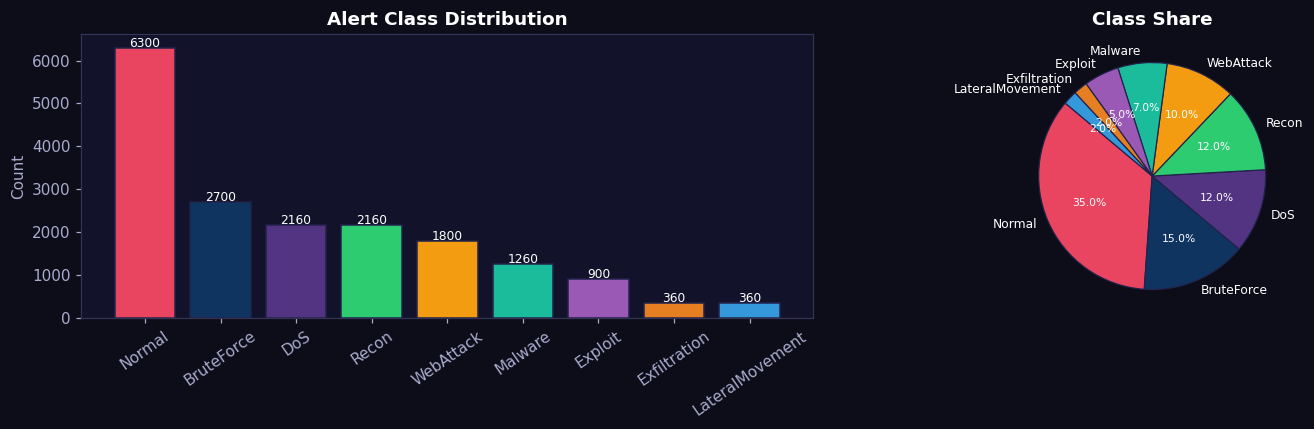

label
Normal             6300
BruteForce         2700
DoS                2160
Recon              2160
WebAttack          1800
Malware            1260
Exploit             900
Exfiltration        360
LateralMovement     360


In [7]:
# ── Class distribution ───────────────────────────────────────────────
lbl_col = "label" if "label" in df.columns else "rule_groups"
vc = df[lbl_col].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.patch.set_facecolor("#0d0d1a")
BG2 = "#12122a"
PALETTE = ["#e94560","#0f3460","#533483","#2ecc71",
           "#f39c12","#1abc9c","#9b59b6","#e67e22","#3498db"]

# Bar chart
ax = axes[0]
ax.set_facecolor(BG2)
bars = ax.bar(vc.index, vc.values, color=PALETTE[:len(vc)], edgecolor="#22224a")
ax.set_title("Alert Class Distribution", color="white", fontweight="bold")
ax.set_ylabel("Count", color="#aaaacc")
ax.tick_params(colors="#aaaacc"); ax.tick_params(axis="x", rotation=35)
for sp in ax.spines.values(): sp.set_edgecolor("#333355")
for b, v in zip(bars, vc.values):
    ax.text(b.get_x()+b.get_width()/2, v+20, str(v),
            ha="center", fontsize=8, color="white")

# Pie chart
ax2 = axes[1]
ax2.set_facecolor(BG2)
wedges, texts, auto = ax2.pie(
    vc.values, labels=vc.index, colors=PALETTE[:len(vc)],
    autopct="%1.1f%%", startangle=140,
    textprops={"color": "white", "fontsize": 8},
    wedgeprops={"edgecolor": "#22224a", "linewidth": 0.8}
)
for t in auto: t.set_fontsize(7)
ax2.set_title("Class Share", color="white", fontweight="bold")

plt.tight_layout()
plt.show()
print(vc.to_string())


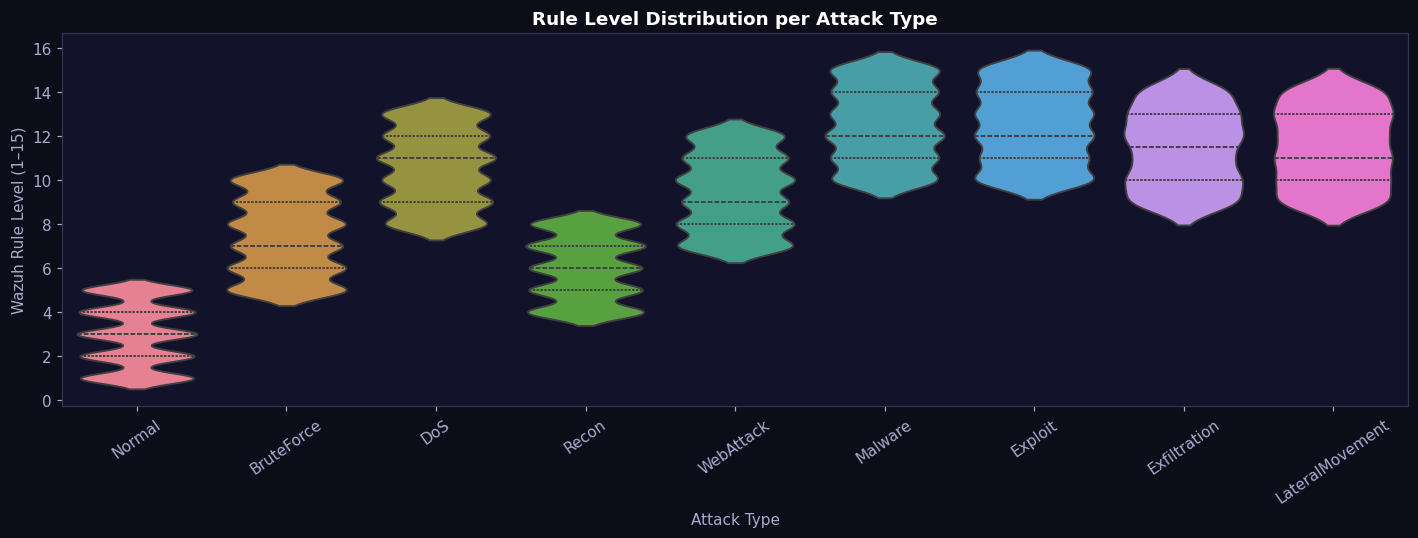

In [8]:
# ── Rule Level distribution per attack type ──────────────────────────
if "label" in df.columns and "rule_level" in df.columns:
    fig, ax = plt.subplots(figsize=(13, 5))
    fig.patch.set_facecolor("#0d0d1a")
    ax.set_facecolor("#12122a")

    attack_order = df["label"].value_counts().index.tolist()
    df_plot = df[df["label"].isin(attack_order)].copy()

    sns.violinplot(
        data=df_plot, x="label", y="rule_level",
        order=attack_order, palette="husl",
        inner="quartile", ax=ax
    )
    ax.set_title("Rule Level Distribution per Attack Type",
                 color="white", fontweight="bold", fontsize=12)
    ax.set_xlabel("Attack Type", color="#aaaacc")
    ax.set_ylabel("Wazuh Rule Level (1–15)", color="#aaaacc")
    ax.tick_params(colors="#aaaacc"); ax.tick_params(axis="x", rotation=35)
    for sp in ax.spines.values(): sp.set_edgecolor("#333355")
    plt.tight_layout()
    plt.show()


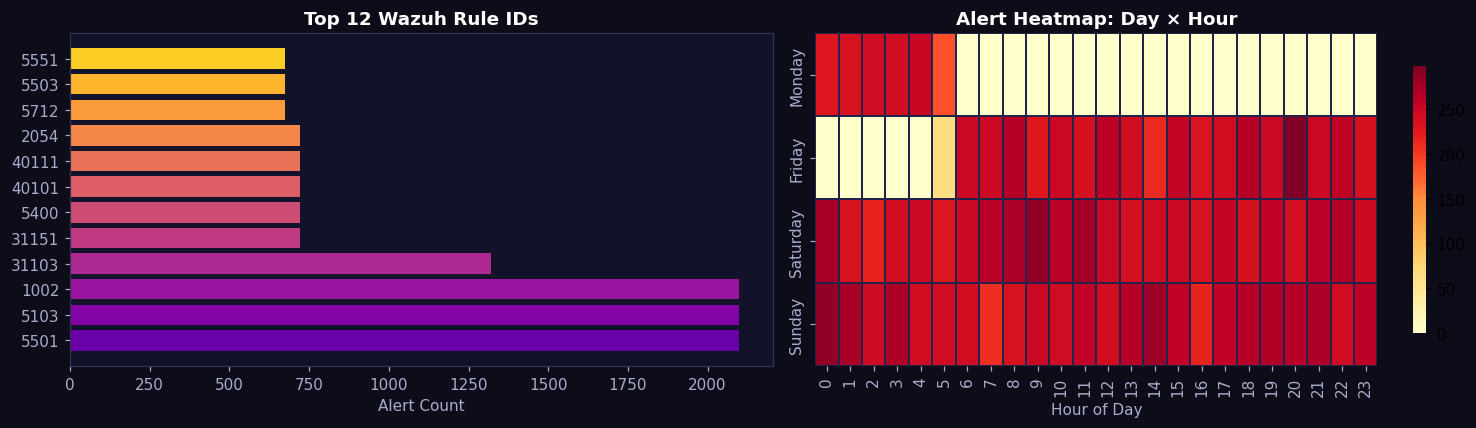

In [9]:
# ── Top Wazuh Rule IDs ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.patch.set_facecolor("#0d0d1a")

for ax in axes:
    ax.set_facecolor("#12122a")
    for sp in ax.spines.values(): sp.set_edgecolor("#333355")
    ax.tick_params(colors="#aaaacc")

# Top rule IDs
top_rules = df["rule_id"].value_counts().head(12)
axes[0].barh(top_rules.index.astype(str), top_rules.values,
             color=plt.cm.plasma(np.linspace(0.2, 0.9, len(top_rules))))
axes[0].set_title("Top 12 Wazuh Rule IDs", color="white", fontweight="bold")
axes[0].set_xlabel("Alert Count", color="#aaaacc")

# Hourly alert heatmap
if "timestamp" in df.columns:
    df["_ts"]   = pd.to_datetime(df["timestamp"], errors="coerce", utc=True)
    df["_hour"] = df["_ts"].dt.hour
    df["_dow"]  = df["_ts"].dt.day_name()
    pivot = df.pivot_table(index="_dow", columns="_hour",
                           values="rule_level", aggfunc="count", fill_value=0)
    day_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
    pivot = pivot.reindex([d for d in day_order if d in pivot.index])
    sns.heatmap(pivot, ax=axes[1], cmap="YlOrRd", linewidths=0.3,
                linecolor="#22224a", cbar_kws={"shrink":0.8})
    axes[1].set_title("Alert Heatmap: Day × Hour", color="white", fontweight="bold")
    axes[1].set_xlabel("Hour of Day", color="#aaaacc")
    axes[1].set_ylabel("")
    axes[1].tick_params(colors="#aaaacc")

plt.tight_layout()
plt.show()


## 🛠️ Cell 7 — Feature Engineering
We extract **34 structured features** from raw Wazuh alert fields, grouped into:
- **Rule features** — level, severity band, MITRE risk score
- **Temporal features** — hour, day-of-week, is_night, is_weekend
- **Network features** — ports, IP octets, protocol flags
- **Behavioural features** — event count, deny/failure flags
- **Compound features** — cross-products that capture co-occurring signals


In [10]:
# ── Label mapping ────────────────────────────────────────────────────
LABEL_MAP = {
    "authentication_failures":"BruteForce","authentication_failed":"BruteForce",
    "brute_force":"BruteForce","web_scan":"BruteForce",
    "dos":"DoS","ddos":"DoS","flood":"DoS",
    "recon":"Recon","scan":"Recon","port_scan":"Recon","network_scan":"Recon",
    "malware":"Malware","ransomware":"Malware","trojan":"Malware","rootkit":"Malware",
    "web":"WebAttack","sql_injection":"WebAttack","xss":"WebAttack","web_attack":"WebAttack",
    "exploit":"Exploit","privilege_escalation":"Exploit","vulnerability":"Exploit",
    "lateral_movement":"LateralMovement","pass_the_hash":"LateralMovement",
    "data_exfiltration":"Exfiltration",
    "syslog":"Normal","ossec":"Normal","pam":"Normal","sshd":"Normal",
}

HIGH_RISK_PORTS = {22, 23, 3389, 445, 4444, 135, 139}

TACTIC_RISK = {
    "initial_access":3, "execution":4, "persistence":5,
    "privilege_escalation":8, "defense_evasion":6, "credential_access":7,
    "discovery":2, "lateral_movement":8, "collection":5,
    "exfiltration":9, "impact":9, "command_and_control":8, "reconnaissance":2,
}

def assign_label(groups_str):
    if not isinstance(groups_str, str): return "Normal"
    for part in groups_str.lower().split(","):
        part = part.strip()
        if part in LABEL_MAP: return LABEL_MAP[part]
        for k, v in LABEL_MAP.items():
            if k in part: return v
    return "Normal"

def rule_band(rule_id):
    try: rid = int(rule_id)
    except: return "other"
    if 5700 <= rid < 5800: return "ssh"
    if 5500 <= rid < 5600: return "auth"
    if 18100 <= rid < 18200: return "windows"
    if 31000 <= rid < 32000: return "web"
    if 40100 <= rid < 40200: return "firewall"
    if 510 <= rid < 560: return "fim"
    return "other"

def ip_features(ip_str):
    try:
        parts = str(ip_str).split(".")
        first = int(parts[0])
        private = (first==10 or
                   (first==172 and 16<=int(parts[1])<=31) or
                   (first==192 and int(parts[1])==168))
        return first, int(private)
    except:
        return 0, 0

def mitre_risk(tactic):
    if not isinstance(tactic, str): return 0
    t = tactic.lower().replace(" ","_")
    for k, v in TACTIC_RISK.items():
        if k in t: return v
    return 1


# ── Build feature matrix ─────────────────────────────────────────────
def build_features(df_raw, le_label=None, le_band=None, training=True):
    d = df_raw.copy()

    # Labels
    if "label" not in d.columns:
        d["label"] = d["rule_groups"].apply(assign_label)

    # Timestamps
    d["_ts"]       = pd.to_datetime(d["timestamp"], errors="coerce", utc=True)
    d["hour"]      = d["_ts"].dt.hour.fillna(12).astype(int)
    d["dow"]       = d["_ts"].dt.dayofweek.fillna(0).astype(int)
    d["is_night"]  = ((d["hour"]<6)|(d["hour"]>22)).astype(int)
    d["is_weekend"]= (d["dow"]>=5).astype(int)

    # Rule
    d["rule_level"]          = pd.to_numeric(d["rule_level"], errors="coerce").fillna(0).astype(int)
    d["rule_high_severity"]  = (d["rule_level"]>=10).astype(int)
    d["rule_medium_severity"]= ((d["rule_level"]>=5)&(d["rule_level"]<10)).astype(int)
    d["rule_band_str"]       = d["rule_id"].apply(rule_band)
    d["mitre_risk"]          = d.get("rule_mitre_tactic", pd.Series([""] * len(d))).apply(mitre_risk)

    # Network
    d["src_port"]    = pd.to_numeric(d.get("src_port",0), errors="coerce").fillna(0).astype(int)
    d["dst_port"]    = pd.to_numeric(d.get("dst_port",0), errors="coerce").fillna(0).astype(int)
    d["event_count"] = pd.to_numeric(d.get("event_count",1), errors="coerce").fillna(1).astype(int)

    d["dst_port_privileged"] = (d["dst_port"]<1024).astype(int)
    d["src_port_privileged"] = (d["src_port"]<1024).astype(int)
    d["dst_high_risk_port"]  = d["dst_port"].apply(lambda p: int(p in HIGH_RISK_PORTS))
    d["same_src_dst_port"]   = (d["src_port"]==d["dst_port"]).astype(int)
    d["log_event_count"]     = np.log1p(d["event_count"])
    d["high_event_count"]    = (d["event_count"]>10).astype(int)

    d[["src_first_octet","src_private"]] = d["src_ip"].fillna("0.0.0.0").apply(
        lambda x: pd.Series(ip_features(x)))
    d[["dst_first_octet","dst_private"]] = d["dst_ip"].fillna("0.0.0.0").apply(
        lambda x: pd.Series(ip_features(x)))
    d["cross_subnet"] = (d["src_first_octet"]!=d["dst_first_octet"]).astype(int)
    d["external_src"] = (1-d["src_private"]).astype(int)

    # Protocol / action / status
    for col in ["protocol","action","status"]:
        if col not in d.columns: d[col] = "unknown"
        d[col] = d[col].fillna("unknown").astype(str).str.lower()

    d["is_deny"]    = d["action"].str.contains("den|drop|block", na=False).astype(int)
    d["is_failure"] = d["status"].str.contains("fail|error",     na=False).astype(int)
    d["is_tcp"]     = (d["protocol"]=="tcp").astype(int)
    d["is_udp"]     = (d["protocol"]=="udp").astype(int)
    d["is_icmp"]    = (d["protocol"]=="icmp").astype(int)

    # Compound
    d["fail_high_severity"]     = d["is_failure"] * d["rule_high_severity"]
    d["deny_high_event"]        = d["is_deny"]    * d["high_event_count"]
    d["external_high_severity"] = d["external_src"] * d["rule_high_severity"]
    d["night_high_severity"]    = d["is_night"]   * d["rule_high_severity"]
    d["high_risk_fail"]         = d["dst_high_risk_port"] * d["is_failure"]
    d["mitre_event_product"]    = d["mitre_risk"] * d["log_event_count"]

    # Encode rule band
    if training:
        le_band = LabelEncoder()
        d["rule_band_enc"] = le_band.fit_transform(d["rule_band_str"])
    else:
        known = set(le_band.classes_)
        d["rule_band_str"] = d["rule_band_str"].apply(lambda x: x if x in known else "other")
        d["rule_band_enc"] = le_band.transform(d["rule_band_str"])

    FEATURE_COLS = [
        "rule_level","rule_high_severity","rule_medium_severity",
        "rule_band_enc","mitre_risk",
        "hour","dow","is_night","is_weekend",
        "src_port","dst_port",
        "dst_port_privileged","src_port_privileged",
        "dst_high_risk_port","same_src_dst_port",
        "log_event_count","high_event_count",
        "src_first_octet","dst_first_octet",
        "src_private","dst_private","cross_subnet","external_src",
        "is_deny","is_failure","is_tcp","is_udp","is_icmp",
        "fail_high_severity","deny_high_event",
        "external_high_severity","night_high_severity",
        "high_risk_fail","mitre_event_product",
    ]

    X = d[FEATURE_COLS].fillna(0).astype(float)

    if training:
        le_label = LabelEncoder()
        y = le_label.fit_transform(d["label"])
        return X, y, FEATURE_COLS, list(le_label.classes_), le_label, le_band
    else:
        return X


# ── Run feature engineering ──────────────────────────────────────────
X, y, FEATURE_COLS, CLASS_NAMES, le_label, le_band = build_features(df, training=True)

print(f"✅ Feature matrix shape : {X.shape}")
print(f"   Classes              : {CLASS_NAMES}")
print(f"   Features ({len(FEATURE_COLS)}):")
for i, f in enumerate(FEATURE_COLS, 1):
    print(f"     {i:2d}. {f}")


✅ Feature matrix shape : (18000, 34)
   Classes              : ['BruteForce', 'DoS', 'Exfiltration', 'Exploit', 'LateralMovement', 'Malware', 'Normal', 'Recon', 'WebAttack']
   Features (34):
      1. rule_level
      2. rule_high_severity
      3. rule_medium_severity
      4. rule_band_enc
      5. mitre_risk
      6. hour
      7. dow
      8. is_night
      9. is_weekend
     10. src_port
     11. dst_port
     12. dst_port_privileged
     13. src_port_privileged
     14. dst_high_risk_port
     15. same_src_dst_port
     16. log_event_count
     17. high_event_count
     18. src_first_octet
     19. dst_first_octet
     20. src_private
     21. dst_private
     22. cross_subnet
     23. external_src
     24. is_deny
     25. is_failure
     26. is_tcp
     27. is_udp
     28. is_icmp
     29. fail_high_severity
     30. deny_high_event
     31. external_high_severity
     32. night_high_severity
     33. high_risk_fail
     34. mitre_event_product


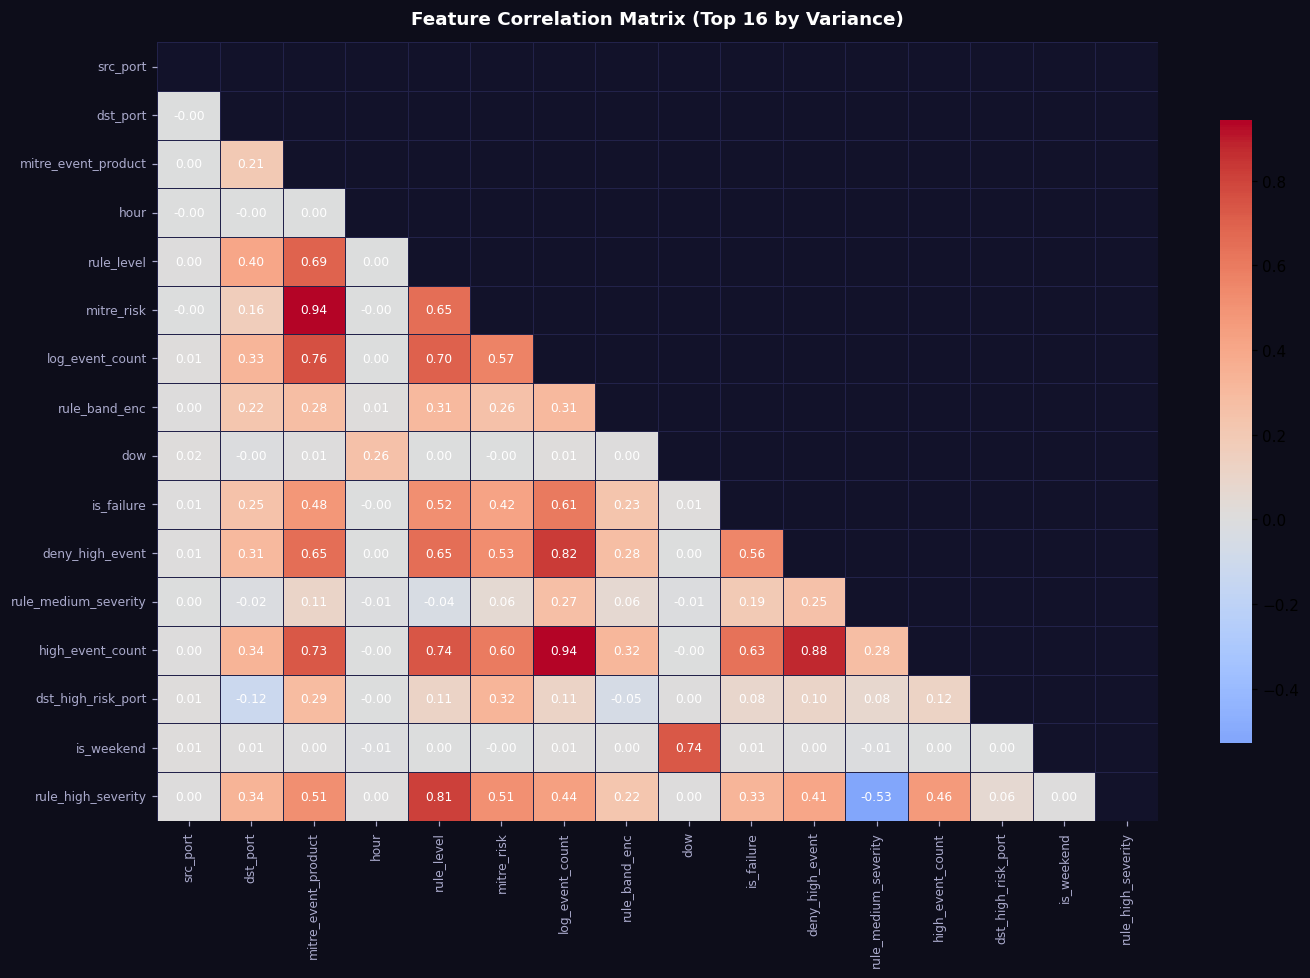

In [11]:
# ── Correlation heatmap of engineered features ───────────────────────
top_by_var = X.var().nlargest(16).index.tolist()

fig, ax = plt.subplots(figsize=(13, 9))
fig.patch.set_facecolor("#0d0d1a")
ax.set_facecolor("#12122a")

corr = X[top_by_var].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, ax=ax, cmap="coolwarm", center=0,
            annot=True, fmt=".2f", annot_kws={"size":8, "color":"white"},
            linewidths=0.4, linecolor="#22224a",
            cbar_kws={"shrink":0.8})
ax.set_title("Feature Correlation Matrix (Top 16 by Variance)",
             color="white", fontweight="bold", fontsize=12, pad=12)
ax.tick_params(colors="#aaaacc", labelsize=8)
plt.tight_layout()
plt.show()


## ✂️ Cell 8 — Train / Test Split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

print(f"✅ Split complete")
print(f"   Total samples : {len(X)}")
print(f"   Train         : {len(X_train)}  ({len(X_train)/len(X)*100:.0f}%)")
print(f"   Test          : {len(X_test)}   ({len(X_test)/len(X)*100:.0f}%)")

# Class balance in train set
train_df = pd.DataFrame({"label": le_label.inverse_transform(y_train)})
print("\n   Train class distribution:")
print(train_df["label"].value_counts().to_string())


✅ Split complete
   Total samples : 18000
   Train         : 14400  (80%)
   Test          : 3600   (20%)

   Train class distribution:
label
Normal             5040
BruteForce         2160
Recon              1728
DoS                1728
WebAttack          1440
Malware            1008
Exploit             720
Exfiltration        288
LateralMovement     288


## 🌲 Cell 9 — Train Random Forest Classifier
**Hyperparameters used:**
| Parameter | Value | Reason |
|---|---|---|
| `n_estimators` | 400 | More trees → lower variance |
| `max_features` | sqrt | Reduces correlation between trees |
| `class_weight` | balanced | Handles imbalanced alert classes |
| `oob_score` | True | Free out-of-bag validation |
| `n_jobs` | -1 | Use all CPU cores |


In [13]:
rf = RandomForestClassifier(
    n_estimators      = 400,
    max_depth         = None,        # grow until pure leaves
    min_samples_split = 4,
    min_samples_leaf  = 2,
    max_features      = "sqrt",
    class_weight      = "balanced",
    oob_score         = True,
    n_jobs            = -1,
    random_state      = 42,
)

print("🌲 Training Random Forest …")
rf.fit(X_train, y_train)

print(f"\n✅ Training complete!")
print(f"   OOB Score    : {rf.oob_score_:.4f}")
print(f"   N estimators : {rf.n_estimators}")
print(f"   N features   : {rf.n_features_in_}")
print(f"   Max depth    : {max(t.get_depth() for t in rf.estimators_)}")


🌲 Training Random Forest …



✅ Training complete!
   OOB Score    : 0.9929
   N estimators : 400
   N features   : 34
   Max depth    : 29


## 📊 Cell 10 — Model Evaluation

In [14]:
y_pred       = rf.predict(X_test)
y_pred_proba = rf.predict_proba(X_test)

acc  = accuracy_score(y_test, y_pred)
f1_w = f1_score(y_test, y_pred, average="weighted")
f1_m = f1_score(y_test, y_pred, average="macro")

print("=" * 52)
print("  EVALUATION METRICS")
print("=" * 52)
print(f"  Accuracy       : {acc:.4f}  ({acc*100:.2f}%)")
print(f"  F1 (Weighted)  : {f1_w:.4f}")
print(f"  F1 (Macro)     : {f1_m:.4f}")
print(f"  OOB Score      : {rf.oob_score_:.4f}")
print("=" * 52)

print("\n  Classification Report:")
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))


  EVALUATION METRICS
  Accuracy       : 0.9911  (99.11%)
  F1 (Weighted)  : 0.9903
  F1 (Macro)     : 0.9683
  OOB Score      : 0.9929

  Classification Report:
                 precision    recall  f1-score   support

     BruteForce       1.00      1.00      1.00       540
            DoS       0.94      1.00      0.97       432
   Exfiltration       0.98      0.61      0.75        72
        Exploit       1.00      1.00      1.00       180
LateralMovement       1.00      1.00      1.00        72
        Malware       1.00      1.00      1.00       252
         Normal       1.00      1.00      1.00      1260
          Recon       1.00      0.99      1.00       432
      WebAttack       1.00      1.00      1.00       360

       accuracy                           0.99      3600
      macro avg       0.99      0.96      0.97      3600
   weighted avg       0.99      0.99      0.99      3600



In [15]:
# ── 5-Fold Cross-Validation ──────────────────────────────────────────
print("Running 5-Fold Stratified Cross-Validation …")
cv        = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf, X, y, cv=cv, scoring="f1_macro", n_jobs=-1)

print(f"\nCV F1-Macro per fold: {cv_scores.round(4)}")
print(f"Mean ± Std          : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")


Running 5-Fold Stratified Cross-Validation …



CV F1-Macro per fold: [0.9725 0.9775 0.9718 0.9837 0.9692]
Mean ± Std          : 0.9749 ± 0.0052


## 📈 Cell 11 — Visualisations

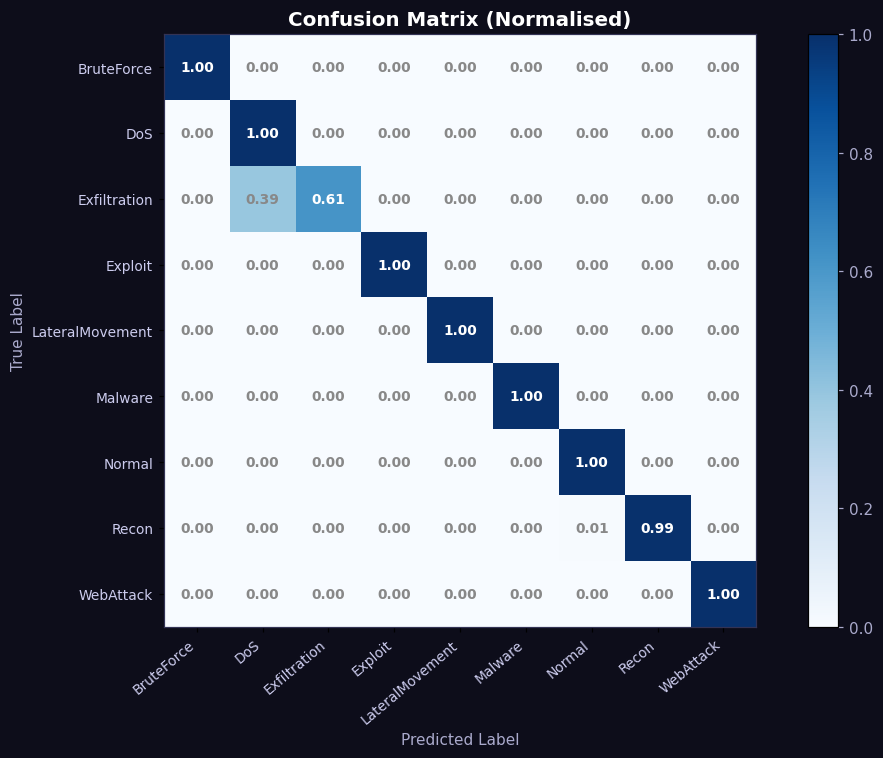

In [16]:
# ── Confusion Matrix ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))
fig.patch.set_facecolor("#0d0d1a")
ax.set_facecolor("#12122a")

cm  = confusion_matrix(y_test, y_pred)
cmn = cm.astype(float) / cm.sum(axis=1, keepdims=True)

im = ax.imshow(cmn, cmap="Blues", vmin=0, vmax=1)
cb = plt.colorbar(im, ax=ax, fraction=0.04)
cb.ax.yaxis.set_tick_params(color="#aaaacc", labelcolor="#aaaacc")

ax.set_xticks(range(len(CLASS_NAMES)))
ax.set_yticks(range(len(CLASS_NAMES)))
ax.set_xticklabels(CLASS_NAMES, rotation=40, ha="right",
                   fontsize=9, color="#ccccee")
ax.set_yticklabels(CLASS_NAMES, fontsize=9, color="#ccccee")
ax.set_title("Confusion Matrix (Normalised)", color="white",
             fontweight="bold", fontsize=13)
ax.set_xlabel("Predicted Label", color="#aaaacc")
ax.set_ylabel("True Label",      color="#aaaacc")

for i in range(len(CLASS_NAMES)):
    for j in range(len(CLASS_NAMES)):
        v = cmn[i,j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=9,
                color="white" if v > 0.5 else "#888888", fontweight="bold")

for sp in ax.spines.values(): sp.set_edgecolor("#333355")
plt.tight_layout()
plt.show()


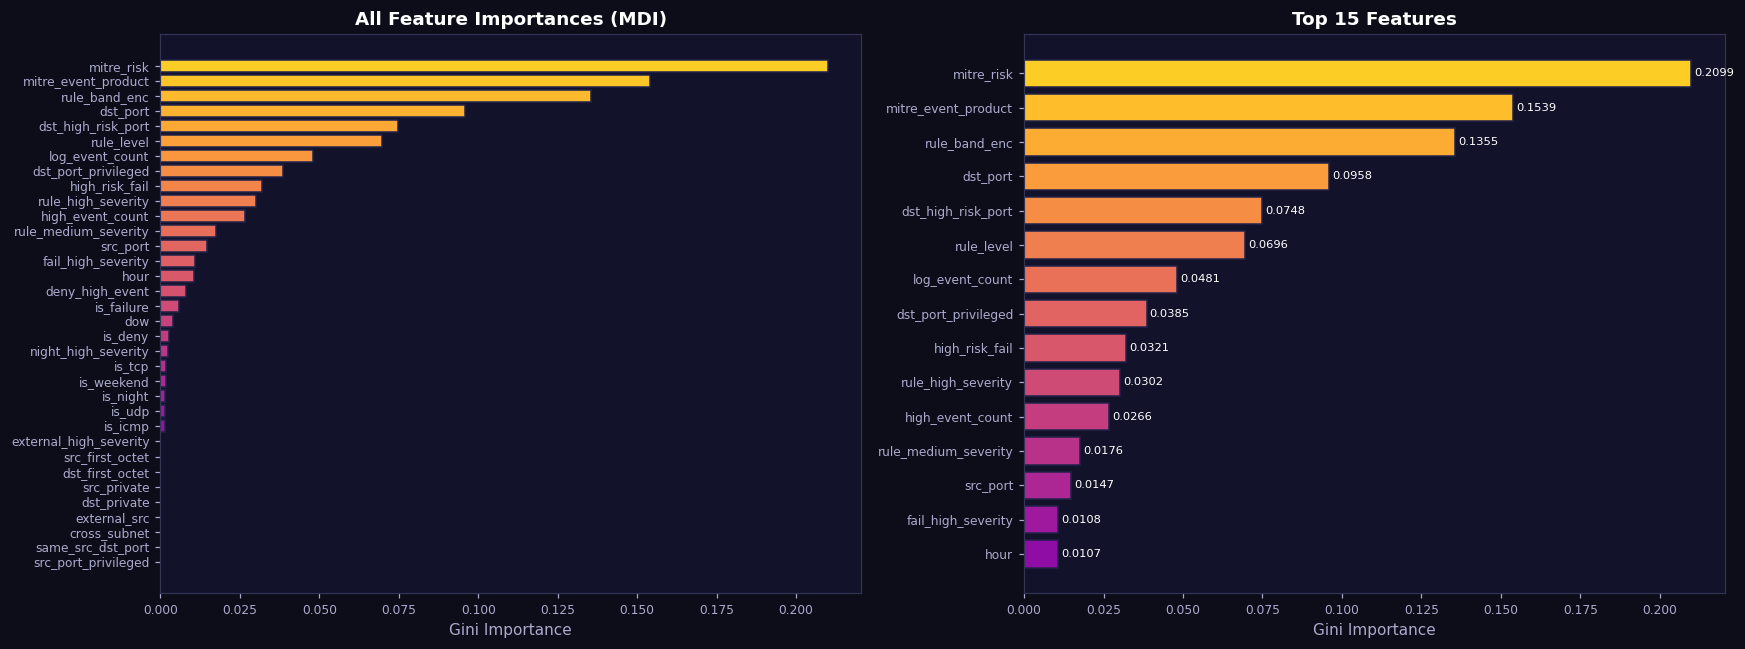

In [17]:
# ── Feature Importances ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor("#0d0d1a")

fi_df = pd.DataFrame({"feature": FEATURE_COLS,
                       "importance": rf.feature_importances_})
fi_df = fi_df.sort_values("importance", ascending=True)

for ax in axes:
    ax.set_facecolor("#12122a")
    for sp in ax.spines.values(): sp.set_edgecolor("#333355")
    ax.tick_params(colors="#aaaacc", labelsize=8)

# All features
bcolors = plt.cm.plasma(np.linspace(0.1, 0.9, len(fi_df)))
axes[0].barh(fi_df["feature"], fi_df["importance"],
             color=bcolors, edgecolor="#22224a")
axes[0].set_title("All Feature Importances (MDI)", color="white", fontweight="bold")
axes[0].set_xlabel("Gini Importance", color="#aaaacc")

# Top 15 with values
top15 = fi_df.tail(15)
bcolors15 = plt.cm.plasma(np.linspace(0.3, 0.9, 15))
bars15 = axes[1].barh(top15["feature"], top15["importance"],
                       color=bcolors15, edgecolor="#22224a")
axes[1].set_title("Top 15 Features", color="white", fontweight="bold")
axes[1].set_xlabel("Gini Importance", color="#aaaacc")
for b, v in zip(bars15, top15["importance"]):
    axes[1].text(v+0.001, b.get_y()+b.get_height()/2, f"{v:.4f}",
                 va="center", fontsize=7.5, color="white")

plt.tight_layout()
plt.show()


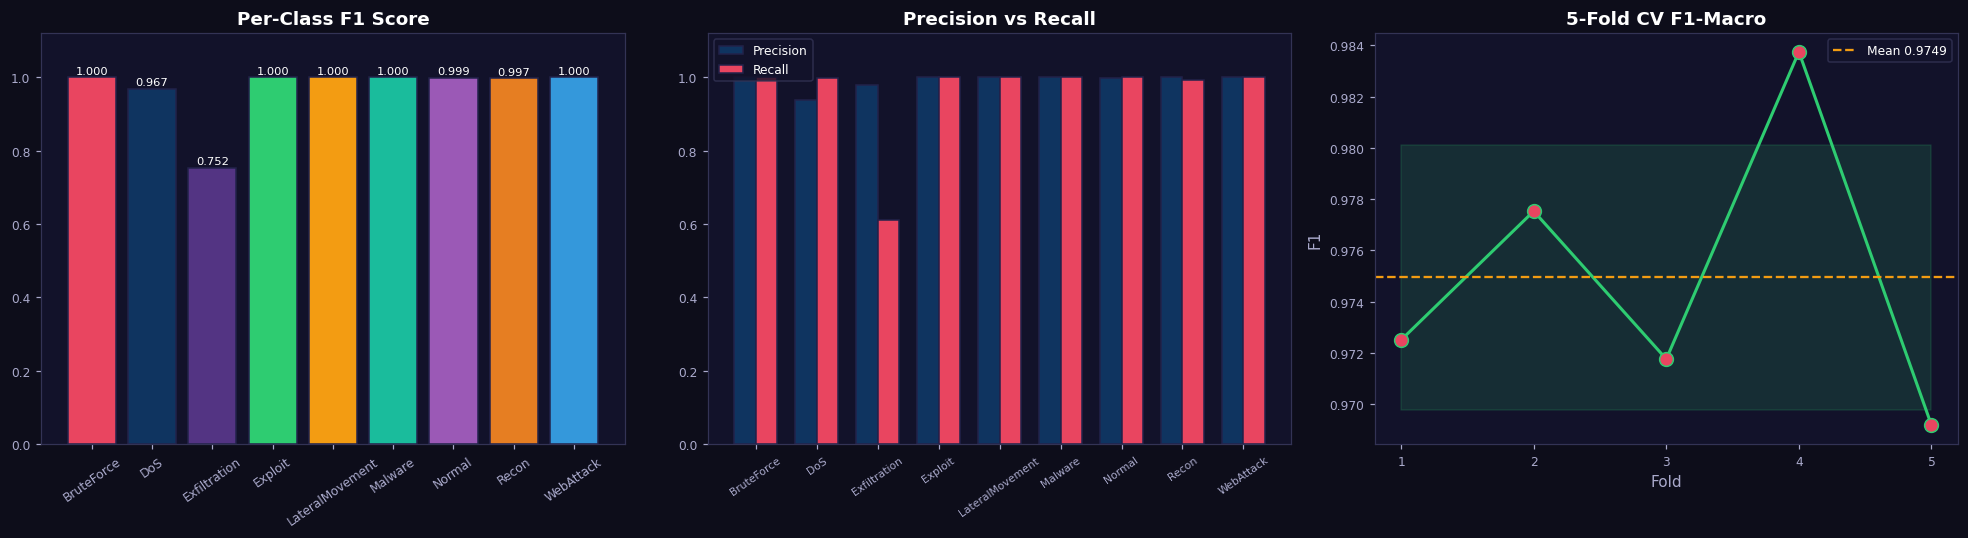

In [18]:
# ── Per-class metrics + CV ───────────────────────────────────────────
report = classification_report(y_test, y_pred, target_names=CLASS_NAMES, output_dict=True)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor("#0d0d1a")
PALETTE = ["#e94560","#0f3460","#533483","#2ecc71",
           "#f39c12","#1abc9c","#9b59b6","#e67e22","#3498db"]

for ax in axes:
    ax.set_facecolor("#12122a")
    for sp in ax.spines.values(): sp.set_edgecolor("#333355")
    ax.tick_params(colors="#aaaacc", labelsize=8)

# F1 per class
f1s = [report[c]["f1-score"] for c in CLASS_NAMES]
b1  = axes[0].bar(CLASS_NAMES, f1s, color=PALETTE[:len(CLASS_NAMES)], edgecolor="#22224a")
axes[0].set_title("Per-Class F1 Score", color="white", fontweight="bold")
axes[0].set_ylim(0, 1.12)
axes[0].tick_params(axis="x", rotation=35)
for b,v in zip(b1,f1s):
    axes[0].text(b.get_x()+b.get_width()/2, v+0.01, f"{v:.3f}",
                 ha="center", fontsize=7.5, color="white")

# Precision vs Recall
prec = [report[c]["precision"] for c in CLASS_NAMES]
rec  = [report[c]["recall"]    for c in CLASS_NAMES]
x_   = np.arange(len(CLASS_NAMES)); w=0.35
axes[1].bar(x_-w/2, prec, w, label="Precision", color="#0f3460", edgecolor="#22224a")
axes[1].bar(x_+w/2, rec,  w, label="Recall",    color="#e94560", edgecolor="#22224a")
axes[1].set_xticks(x_); axes[1].set_xticklabels(CLASS_NAMES, rotation=35, fontsize=7)
axes[1].set_ylim(0, 1.12)
axes[1].set_title("Precision vs Recall", color="white", fontweight="bold")
axes[1].legend(fontsize=8, labelcolor="white", facecolor="#12122a", edgecolor="#333355")

# CV per fold
folds = np.arange(1, len(cv_scores)+1)
axes[2].plot(folds, cv_scores, "o-", color="#2ecc71", lw=2,
             markersize=9, markerfacecolor="#e94560")
axes[2].axhline(cv_scores.mean(), ls="--", color="#f39c12", lw=1.5,
                label=f"Mean {cv_scores.mean():.4f}")
axes[2].fill_between(folds,
                     cv_scores.mean()-cv_scores.std(),
                     cv_scores.mean()+cv_scores.std(),
                     alpha=0.15, color="#2ecc71")
axes[2].set_xticks(folds)
axes[2].set_title("5-Fold CV F1-Macro", color="white", fontweight="bold")
axes[2].set_xlabel("Fold", color="#aaaacc"); axes[2].set_ylabel("F1", color="#aaaacc")
axes[2].legend(fontsize=8, labelcolor="white", facecolor="#12122a", edgecolor="#333355")

plt.tight_layout()
plt.show()


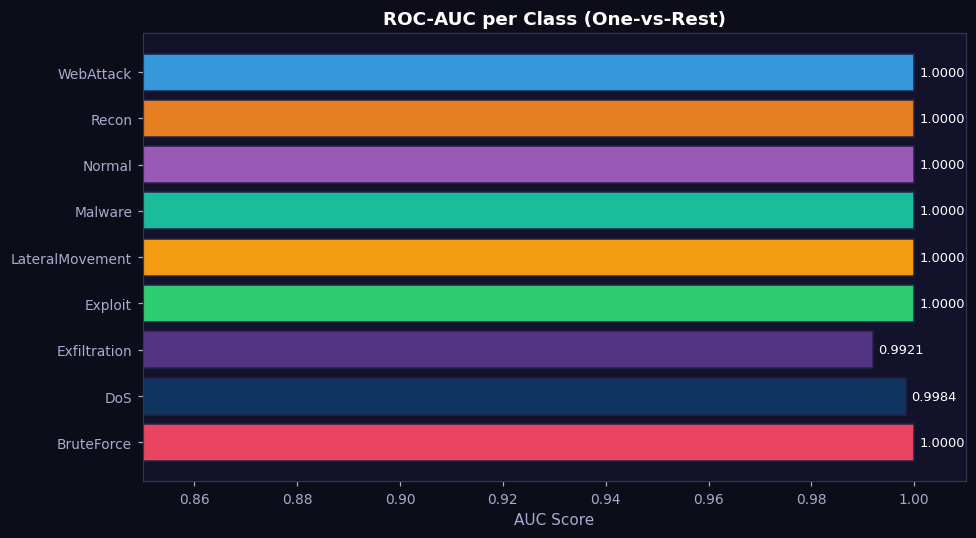


ROC-AUC Summary:
  BruteForce          : 1.0000
  DoS                 : 0.9984
  Exfiltration        : 0.9921
  Exploit             : 1.0000
  LateralMovement     : 1.0000
  Malware             : 1.0000
  Normal              : 1.0000
  Recon               : 1.0000
  WebAttack           : 1.0000
  Mean AUC            : 0.9989


In [19]:
# ── ROC-AUC per class ────────────────────────────────────────────────
y_bin = label_binarize(y_test, classes=range(len(CLASS_NAMES)))
aucs  = []
for i in range(len(CLASS_NAMES)):
    try:    aucs.append(roc_auc_score(y_bin[:,i], y_pred_proba[:,i]))
    except: aucs.append(0.0)

fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor("#0d0d1a"); ax.set_facecolor("#12122a")
for sp in ax.spines.values(): sp.set_edgecolor("#333355")
ax.tick_params(colors="#aaaacc", labelsize=9)

PALETTE = ["#e94560","#0f3460","#533483","#2ecc71",
           "#f39c12","#1abc9c","#9b59b6","#e67e22","#3498db"]
hb = ax.barh(CLASS_NAMES, aucs, color=PALETTE[:len(CLASS_NAMES)], edgecolor="#22224a")
ax.set_xlim(0.85, 1.01)
ax.set_title("ROC-AUC per Class (One-vs-Rest)", color="white",
             fontweight="bold", fontsize=12)
ax.set_xlabel("AUC Score", color="#aaaacc")
for b,v in zip(hb, aucs):
    ax.text(v+0.001, b.get_y()+b.get_height()/2, f"{v:.4f}",
            va="center", fontsize=8.5, color="white")

plt.tight_layout()
plt.show()

print("\nROC-AUC Summary:")
for c, a in zip(CLASS_NAMES, aucs):
    print(f"  {c:<20}: {a:.4f}")
print(f"  {'Mean AUC':<20}: {np.mean(aucs):.4f}")


## 💾 Cell 12 — Save Model for Production

In [20]:
artefact = {
    "model":          rf,
    "label_encoder":  le_label,
    "band_encoder":   le_band,
    "feature_names":  FEATURE_COLS,
    "class_names":    CLASS_NAMES,
    "oob_score":      rf.oob_score_,
    "accuracy":       acc,
    "f1_macro":       f1_m,
    "trained_on":     DATA_SOURCE,
    "n_samples":      len(X),
    "trained_at":     datetime.now().isoformat(),
}

model_path = os.path.join(OUTPUT_DIR, "wazuh_rf_model.pkl")
joblib.dump(artefact, model_path)

print(f"✅ Model saved → {model_path}")
print(f"\n   Metadata:")
for k, v in artefact.items():
    if k not in ("model", "label_encoder", "band_encoder"):
        print(f"     {k:<15}: {v}")


✅ Model saved → ./wazuh_outputs/wazuh_rf_model.pkl

   Metadata:
     feature_names  : ['rule_level', 'rule_high_severity', 'rule_medium_severity', 'rule_band_enc', 'mitre_risk', 'hour', 'dow', 'is_night', 'is_weekend', 'src_port', 'dst_port', 'dst_port_privileged', 'src_port_privileged', 'dst_high_risk_port', 'same_src_dst_port', 'log_event_count', 'high_event_count', 'src_first_octet', 'dst_first_octet', 'src_private', 'dst_private', 'cross_subnet', 'external_src', 'is_deny', 'is_failure', 'is_tcp', 'is_udp', 'is_icmp', 'fail_high_severity', 'deny_high_event', 'external_high_severity', 'night_high_severity', 'high_risk_fail', 'mitre_event_product']
     class_names    : ['BruteForce', 'DoS', 'Exfiltration', 'Exploit', 'LateralMovement', 'Malware', 'Normal', 'Recon', 'WebAttack']
     oob_score      : 0.9929166666666667
     accuracy       : 0.9911111111111112
     f1_macro       : 0.9683239635247559
     trained_on     : SYNTHETIC
     n_samples      : 18000
     trained_at     : 202

## ⚡ Cell 13 — Real-Time Prediction on New Wazuh Alerts
Simulates live alert objects arriving from Wazuh and predicts the attack type instantly.


In [21]:
# ── Simulate 6 incoming Wazuh alerts ────────────────────────────────
new_alerts = [
    {"timestamp":"2025-06-01T02:10:00Z", "rule_id":5712, "rule_level":14,
     "rule_groups":"brute_force,sshd",
     "rule_mitre_tactic":"credential_access",
     "src_ip":"185.220.101.5", "dst_ip":"192.168.10.12",
     "src_port":58432, "dst_port":22,
     "protocol":"tcp", "action":"deny", "status":"failure", "event_count":153},

    {"timestamp":"2025-06-01T09:05:00Z", "rule_id":1002, "rule_level":3,
     "rule_groups":"syslog,ossec",
     "rule_mitre_tactic":"discovery",
     "src_ip":"192.168.10.20", "dst_ip":"192.168.10.1",
     "src_port":50234, "dst_port":80,
     "protocol":"tcp", "action":"allow", "status":"success", "event_count":1},

    {"timestamp":"2025-06-01T03:20:00Z", "rule_id":40111, "rule_level":12,
     "rule_groups":"dos,flood",
     "rule_mitre_tactic":"impact",
     "src_ip":"91.108.4.100", "dst_ip":"192.168.10.15",
     "src_port":40000, "dst_port":443,
     "protocol":"tcp", "action":"drop", "status":"failure", "event_count":8500},

    {"timestamp":"2025-06-01T22:45:00Z", "rule_id":31410, "rule_level":10,
     "rule_groups":"web_attack,sql_injection",
     "rule_mitre_tactic":"initial_access",
     "src_ip":"45.33.32.156", "dst_ip":"192.168.10.12",
     "src_port":61234, "dst_port":8080,
     "protocol":"tcp", "action":"allow", "status":"success", "event_count":4},

    {"timestamp":"2025-06-01T01:15:00Z", "rule_id":18108, "rule_level":13,
     "rule_groups":"lateral_movement,pass_the_hash",
     "rule_mitre_tactic":"lateral_movement",
     "src_ip":"192.168.10.20", "dst_ip":"192.168.10.5",
     "src_port":55000, "dst_port":445,
     "protocol":"tcp", "action":"allow", "status":"success", "event_count":7},

    {"timestamp":"2025-06-01T14:00:00Z", "rule_id":65002, "rule_level":11,
     "rule_groups":"malware",
     "rule_mitre_tactic":"execution",
     "src_ip":"10.0.0.50", "dst_ip":"192.168.10.11",
     "src_port":4444, "dst_port":4444,
     "protocol":"tcp", "action":"allow", "status":"success", "event_count":2},
]

# Fill missing fields
for a in new_alerts:
    for col in ["rule_description","rule_mitre_id","agent_id",
                "agent_name","agent_ip","label"]:
        a.setdefault(col, "N/A")

new_df = pd.DataFrame(new_alerts)
X_new  = build_features(new_df, le_label=le_label, le_band=le_band, training=False)

preds  = rf.predict(X_new)
probas = rf.predict_proba(X_new)

# ── Display results ──────────────────────────────────────────────────
results = []
for i, (a, p, pr) in enumerate(zip(new_alerts, preds, probas)):
    label = CLASS_NAMES[p]
    conf  = pr.max() * 100
    risk  = "🔴 HIGH"  if conf > 80 and label != "Normal" else \
            "🟡 MEDIUM" if conf > 50 and label != "Normal" else "🟢 LOW"
    results.append({
        "Flow": i+1,
        "Src IP":         a["src_ip"],
        "Dst Port":       a["dst_port"],
        "Protocol":       a["protocol"],
        "Rule Level":     a["rule_level"],
        "Predicted":      label,
        "Confidence (%)": round(conf, 2),
        "Risk":           risk,
    })

results_df = pd.DataFrame(results)
display(results_df)

print("\n⚡ Real-time predictions complete!")


,Flow,Src IP,Dst Port,Protocol,Rule Level,Predicted,Confidence (%),Risk
0,1,185.220.101.5,22,tcp,14,BruteForce,74.3900,🟡 MEDIUM
1,2,192.168.10.20,80,tcp,3,Normal,99.9900,🟢 LOW
2,3,91.108.4.100,443,tcp,12,DoS,81.4300,🔴 HIGH
3,4,45.33.32.156,8080,tcp,10,WebAttack,78.9300,🟡 MEDIUM
4,5,192.168.10.20,445,tcp,13,LateralMovement,48.4400,🟢 LOW
5,6,10.0.0.50,4444,tcp,11,Malware,72.8200,🟡 MEDIUM



⚡ Real-time predictions complete!


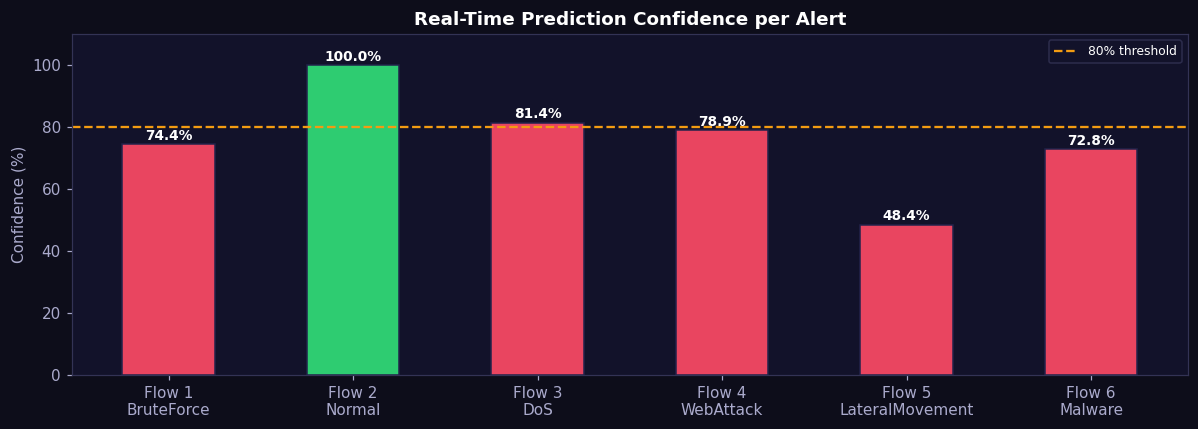

In [22]:
# ── Prediction confidence bar chart ─────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 4))
fig.patch.set_facecolor("#0d0d1a"); ax.set_facecolor("#12122a")
for sp in ax.spines.values(): sp.set_edgecolor("#333355")

labels = [f"Flow {r['Flow']}\n{r['Predicted']}" for r in results]
confs  = [r["Confidence (%)"] for r in results]
colors = ["#e94560" if r["Predicted"] != "Normal" else "#2ecc71" for r in results]

bars = ax.bar(labels, confs, color=colors, edgecolor="#22224a", width=0.5)
ax.axhline(80, ls="--", color="#f39c12", lw=1.5, label="80% threshold")
ax.set_ylim(0, 110)
ax.set_title("Real-Time Prediction Confidence per Alert",
             color="white", fontweight="bold", fontsize=12)
ax.set_ylabel("Confidence (%)", color="#aaaacc")
ax.tick_params(colors="#aaaacc")
ax.legend(fontsize=8, labelcolor="white", facecolor="#12122a", edgecolor="#333355")
for b, v in zip(bars, confs):
    ax.text(b.get_x()+b.get_width()/2, v+1.5, f"{v:.1f}%",
            ha="center", fontsize=9, color="white", fontweight="bold")
plt.tight_layout()
plt.show()


## 🚀 Cell 14 — Production Usage (Load Model & Predict)
This cell shows how to load the saved model and use it for inference in your SOC pipeline.


In [23]:
# ── Load model from disk ─────────────────────────────────────────────
loaded = joblib.load(os.path.join(OUTPUT_DIR, "wazuh_rf_model.pkl"))

rf_loaded  = loaded["model"]
le_loaded  = loaded["label_encoder"]
lb_loaded  = loaded["band_encoder"]
feat_names = loaded["feature_names"]
classes    = loaded["class_names"]

print("✅ Model loaded successfully!")
print(f"   Classes  : {classes}")
print(f"   Features : {len(feat_names)}")
print(f"   Accuracy : {loaded['accuracy']:.4f}")
print(f"   F1 Macro : {loaded['f1_macro']:.4f}")
print(f"   Trained  : {loaded['trained_at']}")

# ── Predict on a single alert ────────────────────────────────────────
def predict_alert(alert_dict, rf_model, le_label, le_band):
    """
    Predict attack type for a single Wazuh alert dictionary.
    Returns (predicted_label, confidence_pct, all_probabilities_dict)
    """
    for col in ["rule_description","rule_mitre_id","agent_id",
                "agent_name","agent_ip","label"]:
        alert_dict.setdefault(col, "N/A")

    single_df = pd.DataFrame([alert_dict])
    X_s = build_features(single_df, le_label=le_label, le_band=le_band, training=False)
    pred  = rf_model.predict(X_s)[0]
    proba = rf_model.predict_proba(X_s)[0]
    label = le_label.inverse_transform([pred])[0]
    conf  = proba.max() * 100
    proba_dict = {le_label.inverse_transform([i])[0]: round(p*100,2)
                  for i, p in enumerate(proba)}
    return label, conf, proba_dict

# Test it
test_alert = {
    "timestamp":         "2025-06-01T23:50:00Z",
    "rule_id":           5712,
    "rule_level":        14,
    "rule_groups":       "brute_force,sshd",
    "rule_mitre_tactic": "credential_access",
    "src_ip":            "198.51.100.5",
    "dst_ip":            "192.168.10.10",
    "src_port":          61999,
    "dst_port":          22,
    "protocol":          "tcp",
    "action":            "deny",
    "status":            "failure",
    "event_count":       245,
}

label, conf, proba_dict = predict_alert(test_alert, rf_loaded, le_loaded, lb_loaded)

print(f"\n⚡ Single Alert Prediction:")
print(f"   Predicted : {label}")
print(f"   Confidence: {conf:.2f}%")
print(f"\n   Class probabilities:")
for cls, prob in sorted(proba_dict.items(), key=lambda x: -x[1]):
    bar = "█" * int(prob / 4)
    print(f"     {cls:<20}: {prob:6.2f}%  {bar}")


✅ Model loaded successfully!
   Classes  : ['BruteForce', 'DoS', 'Exfiltration', 'Exploit', 'LateralMovement', 'Malware', 'Normal', 'Recon', 'WebAttack']
   Features : 34
   Accuracy : 0.9911
   F1 Macro : 0.9683
   Trained  : 2026-04-13T05:44:16.453240



⚡ Single Alert Prediction:
   Predicted : BruteForce
   Confidence: 71.54%

   Class probabilities:
     BruteForce          :  71.54%  █████████████████
     Exploit             :  14.53%  ███
     LateralMovement     :  11.30%  ██
     Malware             :   1.74%  
     Exfiltration        :   0.83%  
     DoS                 :   0.06%  
     WebAttack           :   0.01%  
     Normal              :   0.00%  
     Recon               :   0.00%  


## ✅ Cell 15 — Pipeline Summary & Next Steps

---

### 🧠 Model Summary
| Metric | Value |
|---|---|
| Algorithm | Random Forest Classifier |
| Trees | 400 |
| Features | 34 engineered from Wazuh alerts |
| Classes | 9 attack types |
| Class weight | Balanced (handles imbalanced SIEM data) |
| OOB scoring | ✅ Enabled |

---

### 🔌 To Connect to Real Wazuh
1. Edit **Cell 3** — set `WAZUH_HOST`, `WAZUH_PORT`, `WAZUH_USER`, `WAZUH_PASSWORD`
2. Run **Cell 4** — authenticates with Wazuh Manager REST API
3. Run **Cell 5** — fetches real alerts from OpenSearch (`wazuh-alerts-*`)
4. Re-run **Cells 7–13** to retrain and evaluate on live data

---

### 📡 Real-Time Integration Options
```python
# Option A — Poll Wazuh every N seconds
while True:
    new_raw = fetch_from_indexer(hours=0.016)  # last ~1 minute
    if new_raw:
        new_df = parse_alerts(new_raw)
        X_live = build_features(new_df, le_label, le_band, training=False)
        preds  = rf.predict(X_live)
        # → trigger alerts / push to dashboard
    time.sleep(60)

# Option B — Wazuh Active Response (call this script as a responder)
# Option C — Kafka stream from Wazuh Filebeat → predict per message
```

---

### 🚀 Improvements to Try
- **SHAP explainability** — `shap.TreeExplainer(rf)` for per-alert explanations
- **Hyperparameter tuning** — `RandomizedSearchCV` on real data
- **XGBoost / LightGBM** — often outperform RF on tabular SIEM data
- **Anomaly detection** — `IsolationForest` for unknown zero-day patterns
- **Drift detection** — retrain when alert distribution shifts
